# Issues
- Multi-experiment can be solved for two experiments using D-opt. But the log10 condition number is 13. So, we cannot reliabily invert it and that's why `A-opt` does not solve. We can use `pseudo-A` but it will be just repeating the same experiment.
- The FIM metrics we got after two experiments is very close to the FIM metrics of the prior. So, the experiments aren't adding much information.

# Pyomo.DoE: Multi-experiment design
Multi-experiment design can help resource utilization when parallel experimental setup is available and help with model identifiabilty by providing complementary information.

Maximize a scalar-valued function $\psi(\cdot)$ of the sum of the Fisher information matrices $\mathbf{M}$:
$$
\begin{align*}
\max_{u} \quad & \psi(\sum_{k\in E}\mathbf{M}_k(u_k) + \mathbf{M}_0) \\
\mathrm{s.t.} \quad & C_p^H \frac{dT_{H,k}}{dt} = U_a (T_{amb, k} - T_{H, k}) + U_b (T_{S,k} - T_{H,k}) + \alpha P u_k(t); \; \forall k \in E\\
& C_p^S \frac{dT_{S, k}}{dt} = U_b (T_{H,k} - T_{S,k}); \; \forall k \in E \\
& 0\% \leq u_k(t) \leq 100 \%; \; \forall k \in E\\
& T_{H,k}(t_0) = T_{amb, k}; \; \forall k \in E\\
& T_{S, k}(t_0) = T_{amb, k}; \; \forall k \in E
\end{align*}
$$
Here, $E=\{1, 2, ..., N_{exp}\}$ is the set of experiments in the experimental campaign.
`Pyomo.DoE` automatically formulates, initializes, and solves this optimization problem for $\psi(\cdot) = \log_{10}(\mathrm{trace}(\cdot))$, i.e., A-optimality, and $\psi(\cdot) = \log_{10}(\mathrm{det}(\cdot))$, i.e., D-optimality.

In [1]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_results,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load experimental data (sine test)
We will load the sine test experimental data to serve as an initial point. 

In [2]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


In [3]:
df.describe()

,Time,T1,T2,Q1,Q2
count,901.000000,901.000000,901.000000,901.000000,901.0
mean,450.007902,55.196226,30.713740,49.507214,0.0
std,260.240747,10.824480,3.705279,35.335616,0.0
min,0.000000,22.200000,21.870000,0.000000,0.0
25%,225.010000,49.270000,29.610000,15.000000,0.0
50%,450.010000,56.040000,32.190000,50.000000,0.0
75%,675.010000,63.450000,33.800000,84.000000,0.0
max,900.010000,70.540000,35.090000,100.000000,0.0


Let's visualize the data.

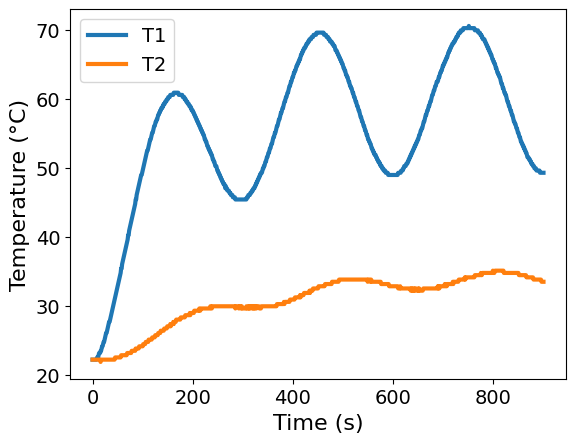

In [4]:
ax = df.plot(x='Time', y=['T1', 'T2'], xlabel='Time (s)', ylabel='Temperature (°C)')

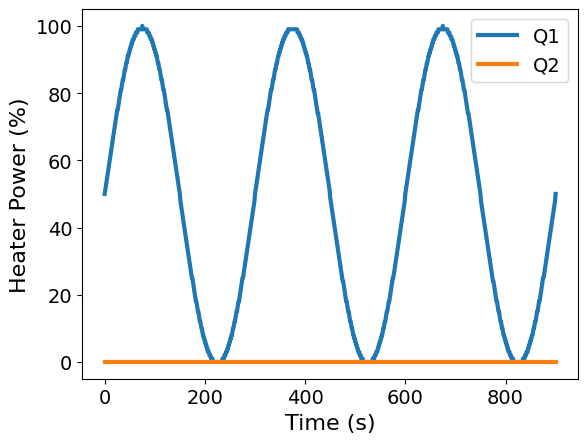

In [5]:
ax = df.plot(x='Time', y=['Q1', 'Q2'], xlabel='Time (s)', ylabel='Heater Power (%)')

We will store the data in an instance of our `TC_Lab_data` dataclass, which converts the numerical data to a  Pandas dataframe

In [6]:
# Here, we will induce a step size of 10 seconds, as to not give too many 
# degrees of freedom for experimental design.
skip = 6
#! Question: Why are we skipping every 10 seconds? For Parmest we did not skip any data
#! so, if we skip data and use the unskipped theta from Parmest, that will be a mismatch. 
# Create the data object considering the new control points every 10 seconds
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

## Calculate the FIM at the already existing experimental data
Since we have one experimental data, we will use the theta value estimated from that experimental data and and compute the FIM using that data.

In [7]:
# Load Pyomo.DoE class
from pyomo.contrib.doe import DesignOfExperiments

from pyomo.environ import SolverFactory

# From the experiment data (Copied from previous notebook)
theta_values = {
    'Ua': 0.0417051733576387,
    'Ub': 0.009440714239773074,
    'inv_CpH': 0.1659093525658045,
    'inv_CpS': 5.8357556063605465,
}

In [8]:
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(
    data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states,
)

# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE = DesignOfExperiments(
    experiment=doe_experiment,
    step=1e-2,
    scale_constant_value=1,
    scale_nominal_param_value=True,
    tee=True,
)

FIM = TC_Lab_DoE.compute_FIM(method='sequential')

Ipopt 3.13.2: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for

In [9]:
results_summary(FIM)

======Results Summary======
Four design criteria log10() value:
A-optimality: 6.374463510874628
D-optimality: 8.296161068941247
E-optimality: -7.60561318054596
Modified E-optimality: 13.928753665992863

FIM:
 [[2068901.63765207    5827.14629912 -257543.79235518   -2735.88055014]
 [   5827.14629912   19935.76143549   49291.98013131   20890.21398003]
 [-257543.79235518   49291.98013131  257574.89939684   56064.19389286]
 [  -2735.88055014   20890.21398003   56064.19389286   22033.82971577]]

eigenvalues:
 [2.10486185e+06 2.48323405e+05 1.52608720e+04 2.47962964e-08]

eigenvectors:
 [[ 9.90385268e-01  1.31473091e-01 -4.30331053e-02 -2.87303565e-07]
 [-5.50731809e-04  2.27368286e-01  6.81976684e-01 -6.95133917e-01]
 [-1.38244138e-01  9.31869612e-01 -3.34606872e-01 -2.33629124e-02]
 [-5.02760034e-03  2.50274879e-01  6.48917712e-01  7.18500530e-01]]


## Optimize two experiments (D-optimality)
We can now optimize two experiments. First we have to create a new instance of `DesignOfExperiments`, and specify the `prior_FIM` (summation of FIMs from already conducted experiment). Since we have only one experiment from the sine test, we will pass that FIM as the `prior_FIM`.

In [10]:
# Create a new experiemnt object for design of experiments, using the same data and theta values as before
# Here, we will induce a step size of 60 seconds, as to not give too many
# degrees of freedom for experimental design.
skip = 20

# Create the data object considering the new control points every 60 seconds
tc_data_2 = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)
# Create experiment object for design of experiments
doe_experiment_1 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
    sine_amplitude=5,
    sine_period=5,
)
doe_experiment_2 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
    sine_amplitude=7,
    sine_period=10,
)


# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_D = DesignOfExperiments(
    experiment=[doe_experiment_1, doe_experiment_2],  # We are optimizing two experiments simultaneously!
    step=1e-2,
    scale_constant_value=1,
    scale_nominal_param_value=True,
    objective_option="determinant",  # Now we specify a type of objective, D-opt = "determinant"
    prior_FIM=FIM,  # We use the prior information from the existing experiment!
    tee=True,
    # use_grey_box_objective=True,
    # grey_box_tee = True,

)

TC_Lab_DoE_D.optimize_experiments()

Ipopt 3.13.2: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for

ValueError: Constraint 'param_scenario_blocks[0].symmetry_breaking_s0_exp1' encountered a strict inequality expression ('>' or '<').  All constraints must be formulated using using '<=', '>=', or '=='.

In [ ]:
TC_Lab_DoE_D.results

{'problem': {'number_of_param_scenarios': 1,
  'number_of_experiments_per_scenario': 2,
  'used_template_experiment': False,
  'finite_difference_scheme': 'central',
  'finite_difference_step': 0.01,
  'scaled_nominal_parameters': True,
  'prior_fim': [[2068901.637652075,
    5827.146299122166,
    -257543.7923551821,
    -2735.880550139573],
   [5827.146299122166, 19935.761435492608, 49291.980131312, 20890.21398003396],
   [-257543.7923551821, 49291.980131312, 257574.89939684182, 56064.1938928585],
   [-2735.880550139573,
    20890.21398003396,
    56064.1938928585,
    22033.82971577397]],
  'measurement_error_values': [np.float64(22.2),
   24.77670526691714,
   28.37185466934054,
   32.190190250202974,
   35.806771934906706,
   38.97482826325777,
   41.587069871972325,
   43.64585467578162,
   45.2419053189435,
   46.531426726542975,
   47.689599412490914,
   48.86361881242954,
   50.14399593288029,
   51.536084006691354,
   52.97070694770424,
   54.32631121285131,
   55.46932821062

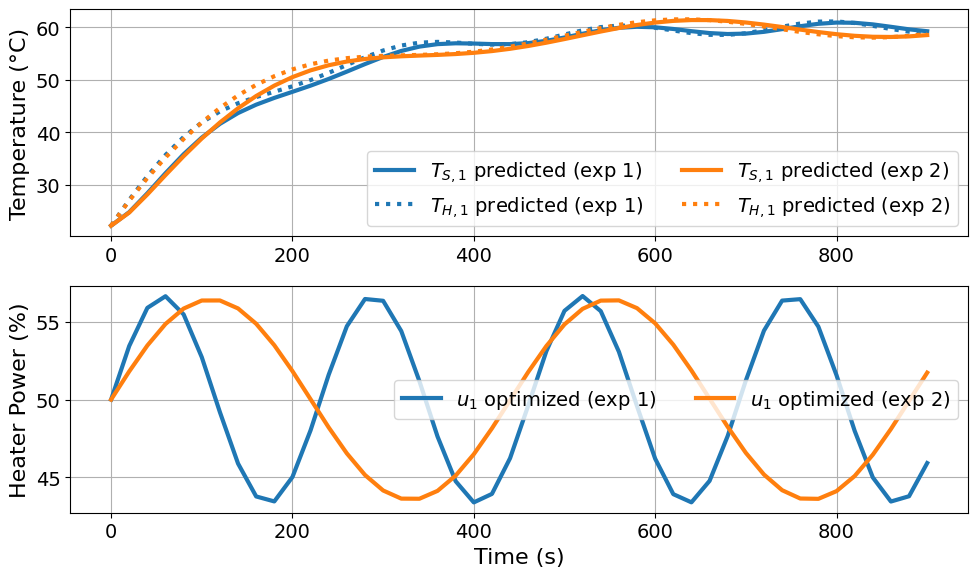

DoE optimize_experiments summary:
parameter scenario: 0
number of experiments: 2
objective: determinant
 


In [ ]:
multiexp_results = extract_plot_results(None, TC_Lab_DoE_D)

In [ ]:
import numpy as np
FIM_total = np.array(
    [[3199764.0220001633,
      -6606.13522702317,
      -422274.6855112547,
      -20120.783337038076],
     [-6606.13522702317,
      22079.141175743316,
      60215.88994793398,
      23319.09011921365],
     [-422274.6855112547,
      60215.88994793398,
      335638.30403665995,
      69171.11376101847],
     [-20120.783337038076,
      23319.09011921365,
      69171.11376101847,
      24809.898997199663]]
)

eigval, eigvec = np.linalg.eig(FIM_total)
print("Eigenvalues:", eigval)
print("Eigenvectors:", eigvec)

Eigenvalues: [3.26107236e+06 3.04657573e+05 1.65614362e+04 3.18418880e-08]
Eigenvectors: [[ 9.89643892e-01 -1.38730058e-01  3.68637798e-02 -2.90589079e-07]
 [-4.74663338e-03 -2.16047099e-01 -6.85631043e-01 -6.95133939e-01]
 [-1.43167480e-01 -9.36340239e-01  3.19725198e-01 -2.33629303e-02]
 [-9.24713367e-03 -2.39467281e-01 -6.52937158e-01  7.18500508e-01]]


## Optimize two experiments (A-optimality)

In [ ]:
# Create a new experiemnt object for design of experiments, using the same data and theta values as before
# Here, we will induce a step size of 60 seconds, as to not give too many
# degrees of freedom for experimental design.
skip = 60

# Create the data object considering the new control points every 60 seconds
tc_data_2 = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)
# Create experiment object for design of experiments
doe_experiment_1 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
    sine_amplitude=5,
    sine_period=5,
)
doe_experiment_2 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
    sine_amplitude=7,
    sine_period=10,
)


# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_A = DesignOfExperiments(
    experiment=[doe_experiment_1, doe_experiment_2],  # We are optimizing two experiments simultaneously!
    step=1e-2,
    scale_constant_value=1,
    scale_nominal_param_value=True,
    objective_option="pseudo_trace",  # Now we specify a type of objective, D-opt = "determinant"
    prior_FIM=FIM,  # We use the prior information from the existing experiment!
    tee=True,
    # use_grey_box_objective=True,
    # grey_box_tee = True,


)

TC_Lab_DoE_A.optimize_experiments()

Ipopt 3.13.2: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for

In [ ]:
TC_Lab_DoE_A.results

{'problem': {'number_of_param_scenarios': 1,
  'number_of_experiments_per_scenario': 2,
  'used_template_experiment': False,
  'finite_difference_scheme': 'central',
  'finite_difference_step': 0.01,
  'scaled_nominal_parameters': True,
  'prior_fim': [[2068901.637652075,
    5827.146299122166,
    -257543.7923551821,
    -2735.880550139573],
   [5827.146299122166, 19935.761435492608, 49291.980131312, 20890.21398003396],
   [-257543.7923551821, 49291.980131312, 257574.89939684182, 56064.1938928585],
   [-2735.880550139573,
    20890.21398003396,
    56064.1938928585,
    22033.82971577397]],
  'measurement_error_values': [np.float64(22.2),
   38.02553723231829,
   52.89081217783988,
   56.9617452858549,
   51.019069321885695,
   44.72291478797013,
   47.070457574786765,
   57.67235321145744,
   67.35099082627725,
   67.44817687345912,
   58.57111869268622,
   50.069529044673494,
   50.77239632110178,
   60.23576293410117,
   69.20298131423974,
   68.86490361669281],
  'design_variables

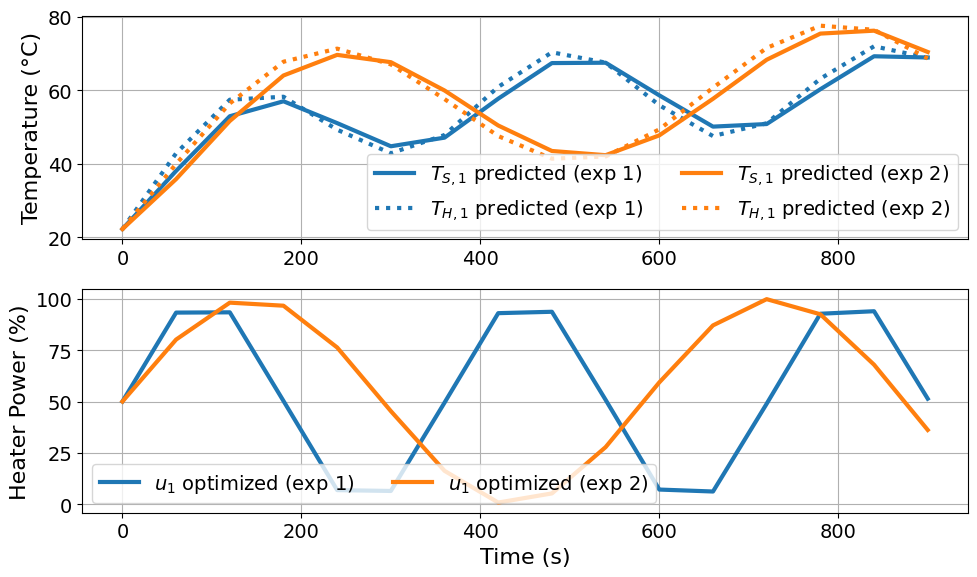

DoE optimize_experiments summary:
parameter scenario: 0
number of experiments: 2
objective: pseudo_trace
 


In [ ]:
multiexp_results = extract_plot_results(None, TC_Lab_DoE_A)

## Time-varying non-sinusoidal input

In [ ]:
# Create a new experiemnt object for design of experiments, using the same data and theta values as before
# Here, we will induce a step size of 60 seconds, as to not give too many
# degrees of freedom for experimental design.
skip = 20

# Create the data object considering the new control points every 60 seconds
tc_data_2 = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)
# Create experiment object for design of experiments
doe_experiment_1 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
    sine_amplitude=5,
    sine_period=5,
)
doe_experiment_2 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
    sine_amplitude=7,
    sine_period=10,
)


# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_D = DesignOfExperiments(
    experiment=[doe_experiment_1],  # We are optimizing two experiments simultaneously!
    step=1e-2,
    scale_constant_value=1,
    scale_nominal_param_value=True,
    objective_option="determinant",  # Now we specify a type of objective, D-opt = "determinant"
    prior_FIM=FIM,  # We use the prior information from the existing experiment!
    tee=True,
    # use_grey_box_objective=True,
    # grey_box_tee = True,

)


TC_Lab_DoE_D.optimize_experiments(
    init_method="lhs",
    n_exp = 2,
    init_n_samples = 10,
    init_parallel=True,
    init_n_workers=8,

)

Ipopt 3.13.2: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for

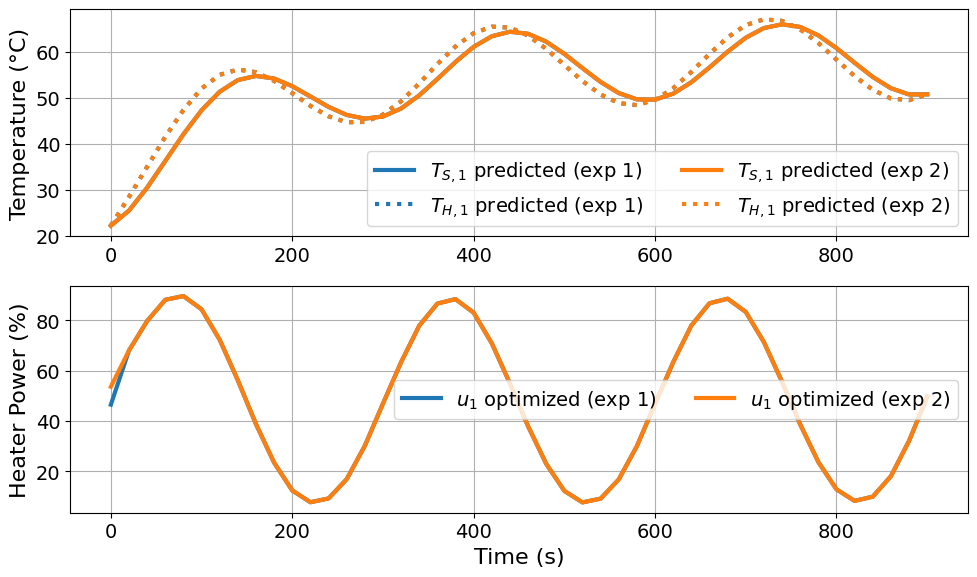

DoE optimize_experiments summary:
parameter scenario: 0
number of experiments: 2
objective: determinant
 


In [ ]:
multiexp_results = extract_plot_results(None, TC_Lab_DoE_D)

In [ ]:
# Create a new experiemnt object for design of experiments, using the same data and theta values as before
# Here, we will induce a step size of 60 seconds, as to not give too many
# degrees of freedom for experimental design.
skip = 20

# Create the data object considering the new control points every 60 seconds
tc_data_2 = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)
# Create experiment object for design of experiments
doe_experiment_1 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
    # sine_amplitude=5,
    # sine_period=5,
)
doe_experiment_2 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
    # sine_amplitude=7,
    # sine_period=10,
)


# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_D = DesignOfExperiments(
    experiment=[doe_experiment_1, doe_experiment_2],  # We are optimizing two experiments simultaneously!
    step=1e-2,
    scale_constant_value=1,
    scale_nominal_param_value=True,
    objective_option="determinant",  # Now we specify a type of objective, D-opt = "determinant"
    prior_FIM=FIM,  # We use the prior information from the existing experiment!
    tee=True,
    # use_grey_box_objective=True,
    # grey_box_tee = True,

)

TC_Lab_DoE_D.optimize_experiments()

Ipopt 3.13.2: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for

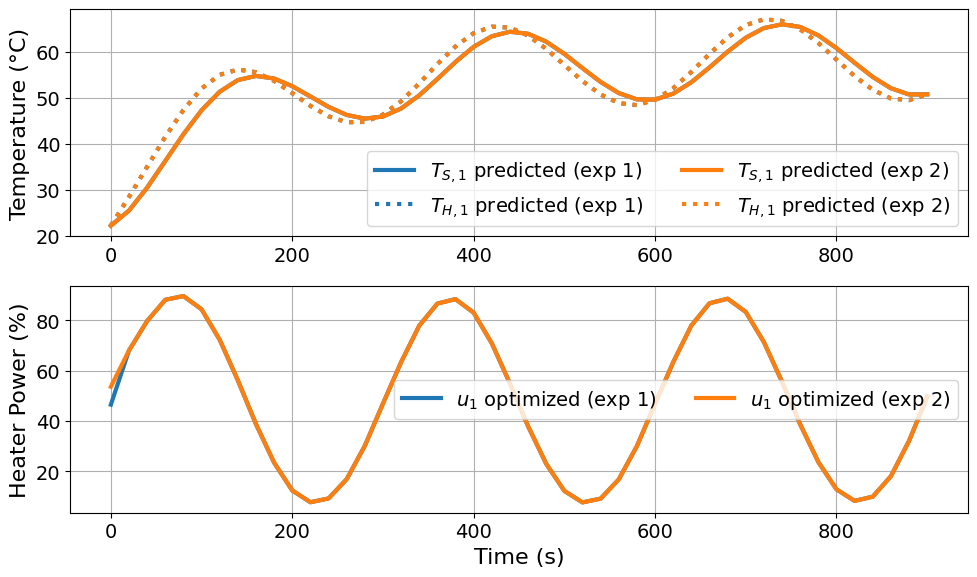

DoE optimize_experiments summary:
parameter scenario: 0
number of experiments: 2
objective: determinant
 


In [ ]:
multiexp_results = extract_plot_results(None, TC_Lab_DoE_D)